# Module 4, Part 1: teaching a line to predict tomorrow's weather

Auckland has a maximum temperature today. Tomorrow it will have another
one. This session asks one question and does not let go of it:

**Given what today's weather looks like, what will tomorrow's maximum
temperature be?**

That question is small enough to sit in a single column of a table, and
big enough to need everything in the first half of Module 4: supervised
learning, a cost function, a line of best fit, the linear algebra you
met in notebook `05-linear-algebra.ipynb`, and the difference between a
model that has seen the answers and one that has not.

## How this session runs

Every section opens with a question and a gap where the answer will be.
**Before I run the cell, commit to an answer** - out loud or in the
chat. A wrong guess costs nothing and is worth more than a right one,
because what you remember afterwards is the distance between your guess
and the output.

There is no number typed into the text of this notebook. Every figure
you see was computed by the cell that printed it, on this data, in front
of you.

## The data

Daily weather for Auckland, from the
[Open-Meteo](https://open-meteo.com/) historical archive (ERA5),
licensed CC BY 4.0. The coordinates are the Auckland Aero AWS station.

Five measurements per day: the maximum and minimum temperature, the rain
that fell, the strongest wind, and the total sunshine energy.

The start and end dates in the request below are pinned on purpose. Left
open, the archive would grow by a row every day, and by next week none of
our answers would match each other's.

In [3]:
# Auckland's daily weather, 2015 to 2026.
# Source: Open-Meteo archive (ERA5), data licensed CC BY 4.0.
# The coordinates are the Auckland Aero AWS station, the same point the
# wx service uses.
import os

import pandas as pd
import requests

CACHE = os.path.join("data", "auckland-daily.csv")

RENAME = {
    "temperature_2m_max": "tmax",
    "temperature_2m_min": "tmin",
    "precipitation_sum": "rain",
    "windspeed_10m_max": "wind",
    "shortwave_radiation_sum": "sun",
}


def load_auckland():
    """Fetch the archive. If that fails, fall back to the saved copy."""
    params = {
        "latitude": -37.0,
        "longitude": 174.8,
        # These two dates are pinned on purpose. Without them the archive
        # grows every day and your answers stop matching the class's.
        "start_date": "2015-01-01",
        "end_date": "2026-09-10",
        "daily": ",".join(RENAME.keys()),
        "timezone": "Pacific/Auckland",
    }
    try:
        response = requests.get(
            "https://archive-api.open-meteo.com/v1/archive",
            params=params,
            timeout=30,
        )
        response.raise_for_status()
        frame = pd.DataFrame(response.json()["daily"]).rename(columns=RENAME)
        print("Fetched live from Open-Meteo.")
    except Exception as problem:
        print("Live fetch failed (%s). Using the saved copy." % type(problem).__name__)
        frame = pd.read_csv(CACHE)
    frame["time"] = pd.to_datetime(frame["time"])
    return frame


weather = load_auckland()
print("rows:", len(weather))
print("from", weather["time"].min().date(), "to", weather["time"].max().date())
weather.head()

Fetched live from Open-Meteo.
rows: 4271
from 2015-01-01 to 2026-09-10


,time,tmax,tmin,rain,wind,sun
0,2015-01-01,20.4,14.4,1.3,23.0,32.82
1,2015-01-02,22.9,13.5,0.0,20.3,31.04
2,2015-01-03,22.6,15.2,0.0,18.4,26.63
3,2015-01-04,23.5,15.2,0.0,12.6,31.38
4,2015-01-05,24.4,17.1,0.0,15.5,28.93


| Column | What it is | Unit |
| --- | --- | --- |
| `time` | the local calendar day in Auckland | date |
| `tmax` | the warmest the air got that day, measured 2 m above the ground | °C |
| `tmin` | the coldest the air got that day, same height | °C |
| `rain` | the depth of water that fell over the whole day | mm |
| `wind` | the fastest sustained wind that day, measured 10 m above the ground | km/h |
| `sun` | the solar energy that landed on one square metre over the day | MJ/m² |

In [4]:
#  https://open-meteo.com/en/docs/historical-weather-api
import requests
import pandas as pd

pd.DataFrame(requests.get("https://archive-api.open-meteo.com/v1/archive?latitude=-37.0&longitude=174.8&" \
"start_date=2015-01-01&end_date=2015-01-01&daily=temperature_2m_max,temperature_2m_min,precipitation_sum," \
"windspeed_10m_max,shortwave_radiation_sum&timezone=Pacific/Auckland").json()["daily"])

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum
0,2015-01-01,20.4,14.4,1.3,23.0,32.82


## Which row holds the answer?

One row per day. The answer we want - tomorrow's maximum - is sitting on
the *next* row. A model never gets to look at the next row; it only ever
sees the row in front of it. So we move the answer backwards by one row
and put tomorrow's maximum onto today's line.

That is one line of pandas. The risk in it is also one line. A shift
assumes the next row really is the next day. If the archive ever skipped
a day, the shift would quietly pair Monday's weather with Wednesday's
temperature, and nothing anywhere would complain.

So we check rather than trust. Before I run it: in an archive assembled
by machine from a reanalysis model, would you expect any missing days?
And whichever way you answer - how would you want the code to behave if
there were?

In [5]:
# We want to predict TOMORROW's maximum. So put tomorrow's answer on
# today's row, by shifting the column up by one.
weather["tmax_tomorrow"] = weather["tmax"].shift(-1)

# A shift is only honest if the next row really is the next day. Check it
# rather than trust it.
weather["gap"] = (weather["time"].shift(-1) - weather["time"]).dt.days

print("gaps between rows:")
print(weather["gap"].value_counts(dropna=False))
print("****************")
usable = weather[weather["gap"] == 1].dropna(subset=["tmax_tomorrow"])
display(usable)
# usable = usable.reset_index(drop=True)
# display(usable)
usable["doy"] = usable["time"].dt.dayofyear
usable["month"] = usable["time"].dt.month
#display(usable)
print()
print("rows we can learn from:", len(usable))
usable[["time", "tmax", "tmax_tomorrow"]].head()

gaps between rows:
gap
1.0    4270
NaN       1
Name: count, dtype: int64
****************


,time,tmax,tmin,rain,wind,sun,tmax_tomorrow,gap
0,2015-01-01,20.4,14.4,1.3,23.0,32.82,22.9,1.0
1,2015-01-02,22.9,13.5,0.0,20.3,31.04,22.6,1.0
2,2015-01-03,22.6,15.2,0.0,18.4,26.63,23.5,1.0
3,2015-01-04,23.5,15.2,0.0,12.6,31.38,24.4,1.0
4,2015-01-05,24.4,17.1,0.0,15.5,28.93,23.3,1.0
...,...,...,...,...,...,...,...,...
4265,2026-09-05,16.8,11.2,0.0,16.1,17.42,17.3,1.0
4266,2026-09-06,17.3,10.1,1.6,21.9,13.96,16.0,1.0
4267,2026-09-07,16.0,11.6,11.0,22.7,8.91,15.7,1.0
4268,2026-09-08,15.7,9.7,0.0,16.0,17.35,16.5,1.0



rows we can learn from: 4270


,time,tmax,tmax_tomorrow
0,2015-01-01,20.4,22.9
1,2015-01-02,22.9,22.6
2,2015-01-03,22.6,23.5
3,2015-01-04,23.5,24.4
4,2015-01-05,24.4,23.3


In [6]:
weather["gap"].value_counts(dropna=False)

gap
1.0    4270
NaN       1
Name: count, dtype: int64

## 1. Which of these two columns is the answer?

*Slides 5 to 7, and 10 to 13.*

Supervised learning has one defining feature, and it is not the
algorithm. It is that **the answers are already in the table**. Every row
carries both halves: what the weather looked like on the day, and the
temperature that actually turned up the next morning. Nothing is being
predicted yet. We are looking up what happened, thousands of times over,
and asking a program to find the rule that joins one side to the other.

Slide 5 gives several names for each side, because different fields
settled on different words. They all mean these two columns.

| The side we look at | The side we want |
| --- | --- |
| input | output |
| independent variable | dependent variable |
| explanatory variable | response variable |
| feature | label, target, outcome |
| predictor | result |

Slide 6 writes the whole thing as $Y = f(X)$, and the rest of this
module is the search for $f$.

### Two questions, one table

Slides 10 to 13 divide problems by what the *answer* looks like, not by
what the data looks like.

- The answer is a number on a scale: that is **regression**. How much?
  How many? What will the temperature be tomorrow?
- The answer is one of a fixed set of labels: that is
  **classification**. Which one? Will the customer renew?

The same table can be asked either question. Out of these two columns we
could build a yes/no answer - *will tomorrow be warmer than today?* -
and that would be a classification problem, with a different cost
function and a different set of tools.

We will build that column once, to see what a classification target
looks like, and then set it aside for the rest of Module 4.

Before I run the cell: over a decade of Auckland days, would you expect
the warmer-tomorrow answers to come out roughly even, or badly lopsided
one way?

In [7]:
# Both halves of the question live in the same table. That is the whole
# of "supervised".
print("what we look at, and what we want, for the first ten days:")
print(usable[["time", "tmax", "tmax_tomorrow"]].head(10).to_string(index=False))

print()
print("input  (the feature) : tmax          - today's maximum, in degrees C")
print("output (the target)  : tmax_tomorrow - tomorrow's maximum, in degrees C")

# The same two columns, asked a yes/no question instead. This is only
# here so you can see what a classification target looks like next to a
# regression one.
usable["warmer_tomorrow"] = usable["tmax_tomorrow"] > usable["tmax"]

print()
print("if we asked 'will tomorrow be warmer?' instead:")
print(usable["warmer_tomorrow"].value_counts())

print()
print("Regression wants the number in tmax_tomorrow.")
print("Classification wants the True/False in warmer_tomorrow.")
print("From here on we use the number. The True/False column is set aside.")

what we look at, and what we want, for the first ten days:
      time  tmax  tmax_tomorrow
2015-01-01  20.4           22.9
2015-01-02  22.9           22.6
2015-01-03  22.6           23.5
2015-01-04  23.5           24.4
2015-01-05  24.4           23.3
2015-01-06  23.3           23.6
2015-01-07  23.6           22.3
2015-01-08  22.3           22.2
2015-01-09  22.2           25.0
2015-01-10  25.0           23.1

input  (the feature) : tmax          - today's maximum, in degrees C
output (the target)  : tmax_tomorrow - tomorrow's maximum, in degrees C

if we asked 'will tomorrow be warmer?' instead:
warmer_tomorrow
True     2198
False    2072
Name: count, dtype: int64

Regression wants the number in tmax_tomorrow.
Classification wants the True/False in warmer_tomorrow.
From here on we use the number. The True/False column is set aside.


## 2. If we always said the same number, how many degrees off would we be?

*Slides 16 to 21.*

Before any model at all, we need a way of saying **how wrong** something
is, in one number. Slide 21 calls that a cost function: it describes how
wrong the model is, by how far its predictions sit from reality.

Here is the arithmetic, for one day at a time. Reality says $y_i$. The
model says $\hat{y}_i$. The gap between them is the **residual**:

$$ e_i \;=\; y_i - \hat{y}_i $$

On slide 23 this is the vertical offset drawn between a point and the
line - the distance straight up or straight down, never diagonally,
because the error is in the answer and not in the question.

We cannot average the residuals as they stand. Half of them are
negative and they would cancel, so a model that is wildly wrong in both
directions would score the same as a perfect one. So each residual is
**squared** first. Squaring throws away the sign, and it charges far more for one
big miss than for several small ones:

$$ \text{MSE} \;=\; \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2 $$

That is the Mean Squared Error slide 21 names. Its units are degrees
*squared*, which nobody has any feel for, so we usually take the square
root and get back to degrees:

$$ \text{RMSE} \;=\; \sqrt{\text{MSE}} $$

Read RMSE as: **a typical day is about this many degrees out**.

### The model everything else has to beat

Now the crudest model there is. It ignores the weather entirely and
always says the same number: the average of all the answers. It is a
bad model, and it is the most useful thing in this session, because
every model that follows has to beat it, and this is the number it has
to beat.

Before I run the cell: guess a number of degrees. If you always said
Auckland's average, how far out would a typical day be?

In [9]:
import numpy as np

# The crudest model there is: ignore every input, always say one number.
# We use the average of the answers we already have.
always_says = usable["tmax_tomorrow"].mean()
print("the one number this model always says: %.4f degrees C" % always_says)

# Do the arithmetic on five days first, slowly, where you can check every
# line of it by eye.
five_days = usable[["time", "tmax_tomorrow"]].head(5).copy()

print()
print("date         actual   guess   residual   residual squared")
for row_number in range(len(five_days)):
    day = five_days.iloc[row_number]
    actual = day["tmax_tomorrow"]
    residual = actual - always_says
    squared = residual ** 2
    print(
        "%s  %6.1f  %6.2f   %8.2f   %16.2f"
        % (day["time"].date(), actual, always_says, residual, squared)
    )

print()
# print("Notice the signs. Some days the guess is too low, some too high.")
# print("Squaring removes the sign, so they cannot cancel each other out.")

the one number this model always says: 18.6385 degrees C

date         actual   guess   residual   residual squared
2015-01-01    22.9   18.64       4.26              18.16
2015-01-02    22.6   18.64       3.96              15.69
2015-01-03    23.5   18.64       4.86              23.63
2015-01-04    24.4   18.64       5.76              33.20
2015-01-05    23.3   18.64       4.66              21.73



Five days is a demonstration, not a measurement. Now the same three
columns of arithmetic on every usable day at once.

The mean of the squared residuals is the MSE; its square root is the
RMSE, back in degrees. We will compute both by hand, and then ask
scikit-learn for the MSE as well, so you can watch the two agree rather
than take it from me.

Before I run it: is your guess from a moment ago still the one you want?

In [10]:
from sklearn.metrics import mean_squared_error

# The same arithmetic as the five-row table, on every row at once.
residuals_mean_model = usable["tmax_tomorrow"] - always_says
squared_residuals = residuals_mean_model ** 2

mse_mean_model = squared_residuals.mean()
rmse_mean_model = mse_mean_model ** 0.5

print("days measured : %d" % len(residuals_mean_model))
print("MSE           : %.3f degrees squared" % mse_mean_model)
print("RMSE          : %.3f degrees" % rmse_mean_model)

# Sanity check: scikit-learn's MSE is the same arithmetic. If these two
# ever disagree, one of them is wrong and it is worth finding out which.
# np.full builds the column of predictions this model makes: one row per
# day, every one of them the same number.
predicted_by_mean_model = np.full(len(usable), always_says)
sklearn_mse = mean_squared_error(usable["tmax_tomorrow"], predicted_by_mean_model)
print()
print("our MSE        :", round(mse_mean_model, 10))
print("sklearn's MSE  :", round(sklearn_mse, 10))
assert np.isclose(mse_mean_model, sklearn_mse), "our MSE and sklearn's disagree"
print("they agree.")


def root_mean_squared_error(actual, predicted):
    """Everything above, in one function we can reuse all session."""
    residuals = actual - predicted
    return (residuals ** 2).mean() ** 0.5


print()
print("the number to beat, in degrees: %.3f" % rmse_mean_model)

days measured : 4270
MSE           : 13.090 degrees squared
RMSE          : 3.618 degrees

our MSE        : 13.0900627881
sklearn's MSE  : 13.0900627881
they agree.

the number to beat, in degrees: 3.618


In [ ]:
rmse_mean_model

## 3. Draw the line before I fit it

*Slides 22 and 23.*

A straight line through a cloud of points is described entirely by two
numbers: where it starts, and how steeply it climbs. The deck writes
those two numbers three different ways, and so does every textbook you
will open. They are the same two numbers every time.

| What it is | Slide 22 | Slide 25 | Many ML books | In this notebook |
| --- | --- | --- | --- | --- |
| where the line crosses the y-axis | $a$ | $\alpha$ | $w_0$ | `intercept` |
| how far y moves per unit of x | $b$ | $\beta$ | $w_1$ | `slope` |

$$ y = a + b\,x \qquad y = \alpha + \beta x \qquad y = w_0 + w_1 x $$

Three spellings, one idea. If a new paper uses a fourth, look for which
symbol multiplies $x$ - that one is the slope, whatever it is called.

First, the picture. Every day is one dot: today's maximum across, the
next day's maximum up.

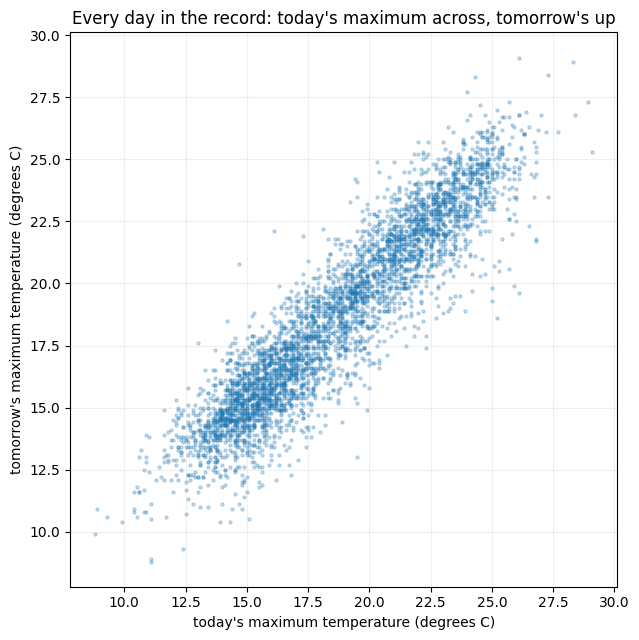

In [11]:
import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(6.5, 6.5))
axis.scatter(usable["tmax"], usable["tmax_tomorrow"], s=5, alpha=0.25)
axis.set_xlabel("today's maximum temperature (degrees C)")
axis.set_ylabel("tomorrow's maximum temperature (degrees C)")
# The title stays neutral on purpose. The next cell asks the room to
# commit to a slope, and a title that named the finding would answer it
# before anybody had to think.
axis.set_title("Every day in the record: today's maximum across, tomorrow's up")
axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Now commit, before any code runs.

Put a ruler through the middle of that cloud. **What slope did you
draw?** Phrase it as a sentence if the number is easier that way: if
today comes out one degree warmer than an ordinary day, how much warmer
is tomorrow - the whole degree, more than a degree, or less?

And the intercept: if today's maximum were zero degrees, what does your
line say about tomorrow?

The cell below works the two numbers out twice. Once from the data with
nothing but numpy, using the formula you met in `07-statistics.ipynb` -
the slope is the covariance of $x$ and $y$ divided by the variance of
$x$, and the line is then forced through the point
$(\bar{x}, \bar{y})$:

$$ b \;=\; \frac{\operatorname{cov}(x, y)}{\operatorname{var}(x)}
\qquad
a \;=\; \bar{y} - b\,\bar{x} $$

And once by handing the columns to scikit-learn's `LinearRegression`.
Two routes, and we assert that they land in the same place.

In [12]:
from sklearn.linear_model import LinearRegression

today = usable["tmax"].values
tomorrow = usable["tmax_tomorrow"].values

today_mean = today.mean()
tomorrow_mean = tomorrow.mean()

# Route one: straight from the definitions, with numpy only.
covariance = ((today - today_mean) * (tomorrow - tomorrow_mean)).mean()
variance = ((today - today_mean) ** 2).mean()

slope_by_hand = covariance / variance
intercept_by_hand = tomorrow_mean - slope_by_hand * today_mean

print("worked out by hand")
print("  slope     :", round(slope_by_hand, 4))
print("  intercept :", round(intercept_by_hand, 4))

# Route two: hand the same two columns to scikit-learn. Note the double
# brackets - sklearn wants a table of features, not a single column.
one_feature_model = LinearRegression()
one_feature_model.fit(usable[["tmax"]], usable["tmax_tomorrow"])

print()
print("worked out by scikit-learn")
print("  slope     :", round(one_feature_model.coef_[0], 4))
print("  intercept :", round(one_feature_model.intercept_, 4))

assert np.isclose(slope_by_hand, one_feature_model.coef_[0]), "slopes disagree"
assert np.isclose(intercept_by_hand, one_feature_model.intercept_), "intercepts disagree"
print()
print("Both routes agree. LinearRegression is not doing anything mysterious.")
print()
print("In words: tomorrow =", round(intercept_by_hand, 4),
      "+", round(slope_by_hand, 4), "x today")

worked out by hand
  slope     : 0.9265
  intercept : 1.3685

worked out by scikit-learn
  slope     : 0.9265
  intercept : 1.3685

Both routes agree. LinearRegression is not doing anything mysterious.

In words: tomorrow = 1.3685 + 0.9265 x today


In [18]:
usable[["tmax"]]

,tmax
0,20.4
1,22.9
2,22.6
3,23.5
4,24.4
...,...
4265,16.8
4266,17.3
4267,16.0
4268,15.7


## 4. Better than guessing the average - but how much better?

*Slide 21 again, now with something worth scoring.*

Section 3 is now answered, so it can be said out loud: tomorrow's
maximum lies in a narrow band around today's. The slope you watched
appear is what "narrow" means here - a degree of change today is
followed by nearly a full degree of change tomorrow, and the intercept
is small. Auckland's weather carries strongly from one day to the next.

Section 2 gave us a number of degrees to beat, and section 3 gave us a
line. The cost function does not care which model produced a prediction;
it only ever compares a column of predictions with a column of answers.
So we can put the two models through exactly the same arithmetic and
read the result off in degrees.

Before I run it: the line uses one measurement that the average-guesser
throws away entirely. How much of the error do you think that one
measurement removes - a tenth of it? Half? Nearly all?

In [13]:
# Same cost function, different model. Nothing else changes.
#predicted_by_line = one_feature_model.predict(usable[["tmax"]])

from sklearn.metrics import mean_squared_error

# How much better is the line than always saying the average?

# Model 1 already exists: predicted_by_mean_model, the same number 4270 times.
# Model 2 is the line, which does look at today.
line_prediction = one_feature_model.predict(usable[["tmax"]])

error_of_average = root_mean_squared_error(usable["tmax_tomorrow"], predicted_by_mean_model)
error_of_line = root_mean_squared_error(usable["tmax_tomorrow"], line_prediction)

print("Typical miss, always saying the average : %.2f degrees C" % error_of_average)
print("Typical miss, using the line            : %.2f degrees C" % error_of_line)
print()
print("The line is wrong by %.2f degrees less." % (error_of_average - error_of_line))
print("That is %.0f%% of the error gone, from one column." %
      (100 * (error_of_average - error_of_line) / error_of_average))
predicted_by_line = one_feature_model.predict(usable[["tmax"]])
rmse_line = root_mean_squared_error(usable["tmax_tomorrow"], predicted_by_line)

Typical miss, always saying the average : 3.62 degrees C
Typical miss, using the line            : 1.36 degrees C

The line is wrong by 2.26 degrees less.
That is 62% of the error gone, from one column.


In [ ]:
predicted_by_mean_model

## 5. Four more columns of weather. How much better?

*Slides 24 to 26.*

The table has four measurements we have not touched: the minimum
temperature, the rain, the wind and the sunshine. Slide 24 says linear
regression uses linear algebra to relate $y$ to *several* $x$ columns at
once, and slide 25 draws it as a matrix.

Each day now gets its own row of the matrix, and each measurement its own
column. The leading column of ones is not a measurement - it is there so
that the intercept can be multiplied by something, which lets the whole
model collapse into a single multiplication:

$$
\begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}
\;=\;
\begin{bmatrix}
1 & x_{1,1} & x_{1,2} & \cdots & x_{1,5} \\
1 & x_{2,1} & x_{2,2} & \cdots & x_{2,5} \\
\vdots & \vdots & \vdots & & \vdots \\
1 & x_{n,1} & x_{n,2} & \cdots & x_{n,5}
\end{bmatrix}
\begin{bmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_5 \end{bmatrix}
$$

which is written $\mathbf{y} = \mathbf{X}\boldsymbol{\beta}$, and which
you have already met. It is $Ax = b$ from `05-linear-algebra.ipynb`, with the unknown
vector renamed. The one difference matters: there are far more rows than
unknowns, so no $\boldsymbol{\beta}$ makes the equation exactly true.
`np.linalg.lstsq` returns the $\boldsymbol{\beta}$ that makes the squared
error as small as it can be - the same cost function from section 2,
minimised in one step rather than searched for.

### Building X from four days, one step at a time

Four days off the top of the table. Two columns matter: `tmax`, which the
model is allowed to look at, and `tmax_tomorrow`, the answer it is trying
to reach.

| date | tmax | tmax_tomorrow |
| :--- | ---: | ---: |
| 2015-01-01 | 20.4 | 22.9 |
| 2015-01-02 | 22.9 | 22.6 |
| 2015-01-03 | 22.6 | 23.5 |
| 2015-01-04 | 23.5 | 24.4 |

**Step 1. The answers become $\mathbf{y}$.** One number per day, stacked:

$$
\mathbf{y} =
\begin{bmatrix}
22.9 \\
22.6 \\
23.5 \\
24.4
\end{bmatrix}
$$

**Step 2. Write the model as a sentence.** Section 3 found these two
numbers:

$$
\text{tomorrow} = 1.3685 + 0.9265 \times \text{today}
$$

There is an awkwardness in that line. The 0.9265 is multiplied by
something. The 1.3685 is not. It just sits there being added.

**Step 3. Give the intercept something to multiply.** Multiplying by one
changes no value at all, so this is the same sentence:

$$
\text{tomorrow} = 1.3685 \times 1 + 0.9265 \times \text{today}
$$

Now both terms have the same shape: a coefficient times a number. That is
the whole trick, and everything below is bookkeeping.

**Step 4. The 1 needs a column to live in.** If every day is multiplied by
a 1, then every day needs a 1 of its own. So a column of them goes in
front of the measurements:

| the 1 | tmax |
| ---: | ---: |
| 1 | 20.4 |
| 1 | 22.9 |
| 1 | 22.6 |
| 1 | 23.5 |

That table is $\mathbf{X}$. The left column is not weather. Nobody
measured it. It exists so the intercept has a partner to be multiplied by.

$$
\mathbf{X} =
\begin{bmatrix}
1 & 20.4 \\
1 & 22.9 \\
1 & 22.6 \\
1 & 23.5
\end{bmatrix}
$$

$$
\boldsymbol{\beta} =
\begin{bmatrix}
1.3685 \\
0.9265
\end{bmatrix}
$$

Read $\boldsymbol{\beta}$ against the columns above it: 1.3685 is the
partner of the ones column, 0.9265 the partner of `tmax`.

**Step 5. Multiply.** Take row one of $\mathbf{X}$ and $\boldsymbol{\beta}$,
pair them off, multiply each pair, add up:

$$
\begin{bmatrix}
1 & 20.4
\end{bmatrix}
\begin{bmatrix}
1.3685 \\
0.9265
\end{bmatrix}
= (1 \times 1.3685) + (20.4 \times 0.9265) = 1.3685 + 18.9006 = 20.2691 \approx 20.27
$$

Do it for all four rows at once and that is $\mathbf{X}\boldsymbol{\beta}$:

$$
\mathbf{X}\boldsymbol{\beta} =
\begin{bmatrix}
1 \times 1.3685 + 20.4 \times 0.9265 \\
1 \times 1.3685 + 22.9 \times 0.9265 \\
1 \times 1.3685 + 22.6 \times 0.9265 \\
1 \times 1.3685 + 23.5 \times 0.9265
\end{bmatrix}
\approx
\begin{bmatrix}
20.27 \\
22.59 \\
22.31 \\
23.14
\end{bmatrix}
$$

**Step 6. Compare with what happened.** Those four numbers are what the
model says. $\mathbf{y}$ is what the sky did:

| date | X beta says | y was | gap |
| :--- | ---: | ---: | ---: |
| 2015-01-01 | 20.27 | 22.9 | +2.63 |
| 2015-01-02 | 22.59 | 22.6 | +0.01 |
| 2015-01-03 | 22.31 | 23.5 | +1.19 |
| 2015-01-04 | 23.14 | 24.4 | +1.26 |


In [16]:
FEATURES = ["tmax", "tmin", "rain", "wind", "sun"]

# Build X exactly as slide 25 draws it: a column of ones, then the
# measurements. The ones column is what the intercept multiplies.
measurements = usable[FEATURES].values
ones_column = np.ones((len(usable), 1))
design_matrix = np.hstack([ones_column, measurements])

print("shape of X:", design_matrix.shape, " (days, 1 + measurements)")
print("shape of y:", tomorrow.shape)
print()
print("the first two rows of X:")
print(design_matrix[:2])

# Route one: solve the least-squares problem directly. lstsq hands back
# four things: the coefficients we want, then the sum of squared
# residuals, the rank of X, and its singular values. The last three are
# diagnostics about the matrix itself, and we do not use them here.
solution, residual_sums, rank, singular_values = np.linalg.lstsq(
    design_matrix, tomorrow, rcond=None
)

print()
print("solved with np.linalg.lstsq")
print("  intercept (beta_0) :", round(solution[0], 4))
for position in range(len(FEATURES)):
    # solution[0] is the intercept, so the features start at index 1.
    print("  %-5s (beta_%d)     : %.4f" % (FEATURES[position], position + 1,
                                           solution[position + 1]))

# Route two: scikit-learn, which adds its own intercept and so does not
# want our column of ones.
five_feature_model = LinearRegression()
five_feature_model.fit(measurements, tomorrow)

print()
print("solved with LinearRegression")
print("  intercept          : %.4f" % five_feature_model.intercept_)
for position in range(len(FEATURES)):
    print("  %-5s              : %.4f" % (FEATURES[position],
                                          five_feature_model.coef_[position]))

# assert np.allclose(solution[0], five_feature_model.intercept_), "intercepts disagree"
# assert np.allclose(solution[1:], five_feature_model.coef_), "coefficients disagree"
print()
print("Same answer from both. scikit-learn is solving the matrix equation.")

predicted_by_five = five_feature_model.predict(measurements)
rmse_five = root_mean_squared_error(tomorrow, predicted_by_five)

print()
print("RMSE in degrees")
print("  always say the average : %.3f" % rmse_mean_model)
print("  today's maximum only   : %.3f" % rmse_line)
print("  all five measurements  : %.3f" % rmse_five)

# Score the four extra columns the same way section 4 scored the first
# one, so the two gains can be read against each other.
gain_from_first_column = rmse_mean_model - rmse_line
gain_from_four_more = rmse_line - rmse_five

# print()
# print("degrees of typical error removed by today's maximum   : %.3f"
#       % gain_from_first_column)
# print("degrees removed by the four extra columns on top      : %.3f"
#       % gain_from_four_more)
# print()
# print("That second number is small. The minimum temperature, the rain,")
# print("the wind and the sunshine, all four together, bought a fraction")
# print("of what the first column bought on its own. Hold on to that -")
# print("it is the reason feature selection is a subject at all.")

shape of X: (4270, 6)  (days, 1 + measurements)
shape of y: (4270,)

the first two rows of X:
[[ 1.   20.4  14.4   1.3  23.   32.82]
 [ 1.   22.9  13.5   0.   20.3  31.04]]

solved with np.linalg.lstsq
  intercept (beta_0) : 3.0681
  tmax  (beta_1)     : 0.7157
  tmin  (beta_2)     : 0.1581
  rain  (beta_3)     : 0.0104
  wind  (beta_4)     : -0.0286
  sun   (beta_5)     : 0.0504

solved with LinearRegression
  intercept          : 3.0681
  tmax               : 0.7157
  tmin               : 0.1581
  rain               : 0.0104
  wind               : -0.0286
  sun                : 0.0504

Same answer from both. scikit-learn is solving the matrix equation.

RMSE in degrees
  always say the average : 3.618
  today's maximum only   : 1.362
  all five measurements  : 1.319


In [19]:
measurements

array([[20.4 , 14.4 ,  1.3 , 23.  , 32.82],
       [22.9 , 13.5 ,  0.  , 20.3 , 31.04],
       [22.6 , 15.2 ,  0.  , 18.4 , 26.63],
       ...,
       [16.  , 11.6 , 11.  , 22.7 ,  8.91],
       [15.7 ,  9.7 ,  0.  , 16.  , 17.35],
       [16.5 ,  6.3 ,  0.  ,  7.6 , 17.35]], shape=(4270, 5))

### What the line became

With one feature the model was a line on a flat page. With two features
it is a flat sheet hanging in three dimensions: today's maximum across,
today's minimum back, tomorrow's maximum up. Every prediction the model
will ever make is a point on that sheet.

With all five it is the same object in six dimensions, which nobody can
draw. Two is the last one we can see, so it is worth seeing.

The plot below fits a model on `tmax` and `tmin` alone and draws its
plane, with a sample of the real days scattered around it. The vertical
distance from each dot to the sheet is a residual - the same idea as in
section 2, measured against a different model, so the same picture but
not the same numbers.

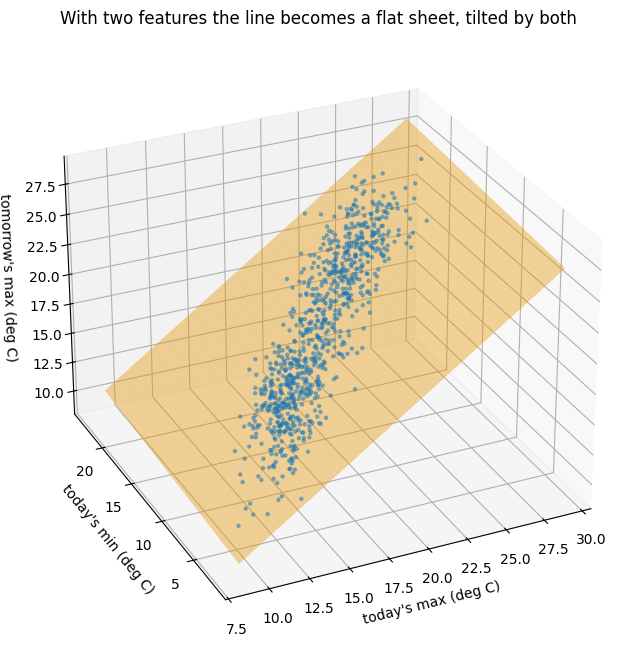

coefficients of the two-feature model
  tmax : 0.8793
  tmin : 0.0544

The sheet stays flat. That is what the 'linear' in linear
regression means - flat in the features, never curved.


In [20]:
two_feature_model = LinearRegression()
two_feature_model.fit(usable[["tmax", "tmin"]].values, tomorrow)

# A grid of possible (today's max, today's min) pairs, so we can ask the
# model what it would predict at every point and draw the answer.
tmax_axis = np.linspace(usable["tmax"].min(), usable["tmax"].max(), 30)
tmin_axis = np.linspace(usable["tmin"].min(), usable["tmin"].max(), 30)
tmax_grid, tmin_grid = np.meshgrid(tmax_axis, tmin_axis)

grid_points = np.column_stack([tmax_grid.ravel(), tmin_grid.ravel()])
predicted_grid = two_feature_model.predict(grid_points).reshape(tmax_grid.shape)

# Every fifth day, so the dots do not bury the sheet.
sample = usable.iloc[::5]

figure = plt.figure(figsize=(9.5, 7))
axis = figure.add_subplot(projection="3d")
axis.scatter(sample["tmax"], sample["tmin"], sample["tmax_tomorrow"],
             s=5, alpha=0.45)
axis.plot_surface(tmax_grid, tmin_grid, predicted_grid,
                  alpha=0.4, color="orange", edgecolor="none")
axis.set_xlabel("today's max (deg C)")
axis.set_ylabel("today's min (deg C)")
axis.set_zlabel("tomorrow's max (deg C)", labelpad=8)
axis.set_title("With two features the line becomes a flat sheet, tilted by both")
# Chosen so the sheet is seen at an angle rather than edge on.
axis.view_init(elev=28, azim=-115)
# tight_layout does not handle 3D axes, so the margins are set by hand.
figure.subplots_adjust(left=0.02, right=0.90, top=0.94, bottom=0.06)
plt.show()

print("coefficients of the two-feature model")
print("  tmax : %.4f" % two_feature_model.coef_[0])
print("  tmin : %.4f" % two_feature_model.coef_[1])
print()
print("The sheet stays flat. That is what the 'linear' in linear")
print("regression means - flat in the features, never curved.")

## 6. Random split, or split by date - which one flatters the model?


Every RMSE so far has been measured on the same days the model learned
from. That is marking your own homework with the answer sheet open. A
model is only worth anything on days it has never seen, so slides 30 and
31 split the data: most of it to train on, the rest held back and not
looked at until the end. Seventy for training and thirty for testing is
the usual starting point, and it is a convention rather than a law.

Slide 31 says the split must be random, and for most tables that is
exactly right - a random split protects you from any accidental order in
the rows. This table, though, has a direction built into it. The rows
are days, in order, and the real job is to predict days that have not
happened yet.

So there are two ways to cut it.

- **Split at random.** Thirty per cent of the days are drawn at random
  for the test set, with no regard to when they fall. The days that go
  each way are scattered right through the record, so the model can
  train on a Monday and a Wednesday and then be tested on the Tuesday
  in between.
- **Split by date.** Everything before a chosen date trains; everything
  after it is the test set. The model has never seen a day from the test
  period.

Both are below, fitted on the same five features, scored with the same
cost function.

Before I run it: which of the two do you expect to report the *lower*
error - and is the lower number the more honest one?

In [ ]:
from sklearn.model_selection import train_test_split

# Split one: by date. Everything before 2024 trains, everything from
# 2024 onwards is a test period the model has never seen.
# is_training_day is a column of True/False, one per day. The tilde in
# ~is_training_day means "not", so it flips every True to False and
# picks out the test days instead.
is_training_day = (usable["time"] < "2024-01-01").values

time_split_model = LinearRegression()
time_split_model.fit(measurements[is_training_day], tomorrow[is_training_day])

time_split_prediction = time_split_model.predict(measurements[~is_training_day])
time_split_rmse = root_mean_squared_error(
    tomorrow[~is_training_day], time_split_prediction
)

print("split by date")
print("  training days : %d" % int(is_training_day.sum()))
print("  test days     : %d" % int((~is_training_day).sum()))
print("  test RMSE     : %.3f degrees" % time_split_rmse)

# Split two: at random, the way slide 31 describes. random_state pins the
# shuffle so that everyone in the room gets the same split.
train_x, test_x, train_y, test_y = train_test_split(
    measurements, tomorrow, test_size=0.3, random_state=42
)

random_split_model = LinearRegression()
random_split_model.fit(train_x, train_y)
random_split_rmse = root_mean_squared_error(test_y, random_split_model.predict(test_x))

print()
print("split at random")
print("  training days : %d" % len(train_y))
print("  test days     : %d" % len(test_y))
print("  test RMSE     : %.3f degrees" % random_split_rmse)

print()
print("difference in degrees : %.3f" % (time_split_rmse - random_split_rmse))
print()
# print("Read that difference as a direction, not as a penalty. The two")
# print("models sat different exams - different days, and different")
# print("numbers of them - so the gap is not a like-for-like measurement")
# print("of what the time split costs.")
# print()
# print("The random split scatters test days between training days. Its")
# print("test set is surrounded by days the model has already studied, so")
# print("it is an easier exam than the one the model sits in real life.")

Now look at the harder exam happening. The cell below plots the held-out
period in time order: what actually happened, and what the model
predicted, day by day, for years it never saw.

Before I run it: at this scale, do you expect the two lines to look
noticeably different - and if they part company, where in the year?

In [ ]:
test_days = usable.loc[~is_training_day, "time"]

figure, axis = plt.subplots(figsize=(13, 4.5))
axis.plot(test_days, tomorrow[~is_training_day], linewidth=0.8,
          label="what happened")
axis.plot(test_days, time_split_prediction, linewidth=0.8, alpha=0.8,
          label="what the model predicted")
axis.set_xlabel("date (test period only - the model never saw these days)")
axis.set_ylabel("tomorrow's maximum temperature (degrees C)")
axis.set_title("The model tracks the seasons closely and misses the sharpest daily swings")
axis.legend()
axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Where the misses are worst, by month, on the held-out period only.
test_frame = usable.loc[~is_training_day, ["month"]].copy()
test_frame["absolute_error"] = np.abs(tomorrow[~is_training_day] - time_split_prediction)

print("mean absolute error by month, test period only (degrees)")
print(test_frame.groupby("month")["absolute_error"].mean().round(3).to_string())

## 8. Where this goes next

*Slides 32 and 33.*

### Lab 4.1.1 - Linear Regression From Scratch

Builds the line the way section 3 did, from the definitions, on the
lab's own sample data. You have now seen every step of it run, so treat
the lab as a chance to type the arithmetic yourself rather than as new
material. If a cell in the lab surprises you, come back to section 3 and
compare.

### Lab 4.1.2 - Splitting Data

Section 7 in the lab's own words, on data from scikit-learn. Keep one
question in mind the whole way through: on the lab's dataset, is there a
direction in the rows the way there is in ours? If there is not, the
random split is the right one and nothing here contradicts it.

### What Part 2 answers

Three questions are now open, and each has a section of the next session
waiting for it.

1. Our error is in degrees, which means it cannot be compared with a
   model that predicts rainfall in millimetres, or house prices in
   dollars. Is there a way to say how good a model is that does not
   depend on the units - and against what would you measure it? Section
   2 already built the thing it gets measured against.
2. Five measurements went into the model and all five came out with a
   coefficient. Were all five earning their place? What happens to the
   score if we add a column of pure nonsense?
3. The line is flat, and the seasons are not. What happens if we let the
   model bend - and how much bending is too much?

Bring the questions. Part 2 starts with the first one.

---

*Data Science and AI, Module 4 Part 1. Weather data from
[Open-Meteo](https://open-meteo.com/), licensed CC BY 4.0. Built by
`tools/build_17_regression.py`.*